# Credit Card Fraud Detection — Live Demo (2 hours)

**Dataset:** Kaggle "Credit Card Fraud Detection"
https://www.kaggle.com/mlg-ulb/creditcardfraud

Download `creditcard.csv` from the link above and place it in the same
folder as this script (or update DATA_PATH below).

Run this file in VS Code's Interactive Window (each `# %%` block is a
separate "cell" — click "Run Cell" or press Shift+Enter).

A suggested 2-hour teaching timeline is at the very bottom of this file.

### Setup (run once before class)
This notebook loads the dataset directly from Kaggle via `kagglehub`,
so no manual download/unzip is needed. Install the dependency once:

```
pip install kagglehub[pandas-datasets]
```

You'll also need a Kaggle account with an API token configured
(kagglehub will prompt you to log in / paste a token the first time).

## 1. Business Problem

A bank processes thousands of card transactions every minute. Most are
legitimate, but a small number are fraudulent. We want a model that looks
at a transaction's features and predicts:

- `0` → Legitimate transaction
- `1` → Fraudulent transaction

This is a **binary classification problem**.

Why it matters:
- Missing a fraud (False Negative) costs the bank / customer real money.
- Flagging a legitimate transaction as fraud (False Positive) annoys
  customers and creates support overhead.
- Fraud is RARE compared to legitimate transactions, which makes this a
  classic **imbalanced classification** problem — the main challenge
  we'll explore today.

In [4]:
# ## 2. Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Make plots look a bit nicer by default
sns.set_style("whitegrid")

# Download the dataset folder from Kaggle (downloads + caches on first run)
dataset_path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Find the CSV inside the downloaded folder and load it normally
csv_path = os.path.join(dataset_path, "creditcard.csv")
df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
df.head()

100%|██████████| 66.0M/66.0M [00:11<00:00, 5.80MB/s]

Extracting files...


Dataset loaded successfully.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### A quick note on the columns
- `Time`: seconds elapsed since the first transaction in the dataset.
- `V1` ... `V28`: anonymized features created via PCA (the bank could not
  share raw features for privacy reasons — this is common in real fraud
  datasets).
- `Amount`: transaction amount.
- `Class`: our **target** — 0 = legitimate, 1 = fraud.

In [5]:
# ## 3. Quick EDA

# Shape of the dataset
print("Shape (rows, columns):", df.shape)

# First few rows
df.head()

Shape (rows, columns): (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Missing values check
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values in the dataset")

Missing values per column:
0 total missing values in the dataset


In [7]:
# Target distribution (counts and percentages)
class_counts = df["Class"].value_counts()
class_percent = df["Class"].value_counts(normalize=True) * 100

print("Counts:\n", class_counts)
print("\nPercentages:\n", class_percent.round(3))

Counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Percentages:
 Class
0    99.827
1     0.173
Name: proportion, dtype: float64


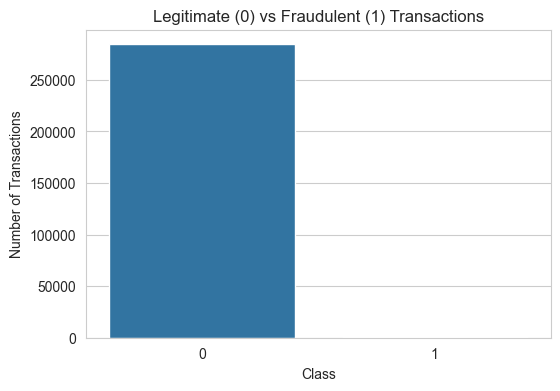

In [8]:
# Visualize legitimate vs fraudulent transaction counts
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df)
plt.title("Legitimate (0) vs Fraudulent (1) Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

# The bar for fraud (1) is barely visible — that's the imbalance problem!

## 4. Imbalanced Data

Notice from the plot and percentages above: fraudulent transactions are
roughly **0.17% of the dataset**. Legitimate transactions make up the
other ~99.83%.

### Why this matters
Imagine a "lazy model" that predicts `0` (legitimate) for EVERY single
transaction, no matter what. Let's check what accuracy that lazy model
would get.

In [9]:
lazy_accuracy = (df["Class"] == 0).mean() * 100
print(f"A model that always predicts 'legitimate' would score "
      f"{lazy_accuracy:.2f}% accuracy!")

# This model is completely useless — it never catches a single fraud —
# yet its accuracy looks excellent. This is exactly why we CANNOT judge
# a fraud model using accuracy alone. We need metrics that focus on how
# well the model finds the rare fraud cases: Precision, Recall, F1-score,
# and ROC-AUC (all covered later in this notebook).

A model that always predicts 'legitimate' would score 99.83% accuracy!


## 5. Preprocessing

Steps:
1. Separate features (X) from target (y).
2. Split into train and test sets BEFORE scaling (to avoid data leakage —
   the test set must remain completely unseen during training).
3. Scale features — fit the scaler on the training data only, then use
   it to transform both train and test data.

### Why scaling matters for KNN and SVM
- **KNN** classifies a point based on the *distance* to its neighbors.
  If `Amount` ranges up to thousands while `V1`...`V28` are small PCA
  values, `Amount` alone would dominate the distance calculation.
- **SVM** tries to find the best separating boundary based on margins/
  distances too, so features on very different scales distort the
  boundary it learns.
- Logistic Regression and Naive Bayes are less sensitive to scale, but
  scaling doesn't hurt them, so we apply it consistently to all models
  for simplicity.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Separate X (features) and y (target)
X = df.drop("Class", axis=1)
y = df["Class"]

# Step 2: Train/test split BEFORE scaling (avoid data leakage)
# stratify=y keeps the same fraud/legit ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (199364, 30)
Test set shape: (85443, 30)


In [11]:
# Step 3: Scale features (fit on train, transform train and test)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)          # transform ONLY on test

print("Scaling complete. Example of scaled values:")
print(X_train_scaled[:2])

Scaling complete. Example of scaled values:
[[ 1.25799168e+00 -5.57826383e-03  4.27819302e-01  1.08346890e-01
  -5.34196278e-01  4.25863683e-01 -4.89116243e-01  6.76802298e-01
  -3.17973776e-04 -1.69657901e-01 -2.04596939e-01  3.71250945e-01
   3.84924806e-01 -6.52690971e-01  4.36586368e-01 -1.10396938e+00
   2.60220428e-01 -8.72575294e-01 -8.08109117e-02  4.04491892e-01
  -4.80497380e-02 -3.13204003e-01 -7.88791216e-01  6.70733037e-02
  -5.96328746e-01 -9.47612636e-01  2.95700262e-01  5.79622746e-01
   2.52461592e-01 -3.21082095e-01]
 [ 9.39712889e-01  9.04109150e-01 -1.10138288e-01 -1.44936147e+00
   8.40920356e-01  4.42775857e-01 -7.60781903e-01  7.36596284e-01
  -3.22161901e-01 -2.91514578e-01  4.73741681e-01  4.81193941e-01
   2.46875182e-01 -1.06035604e+00  1.29602063e+00 -4.74665365e-01
  -1.53534910e-01 -8.51351530e-01  3.91442528e-01 -2.03885826e-02
  -3.78882627e-02  3.79248709e-01  7.29482488e-01 -3.72721352e-01
  -5.65282436e-01  9.45219119e-01 -8.87093982e-01 -1.83513402e-

## 6. Train Four Models

We'll train four classic classifiers using mostly default settings.
The goal today is to *compare* them, not to squeeze out maximum
performance (no hyperparameter tuning).

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# 1. Logistic Regression — a simple linear model, great baseline for
#    binary classification. max_iter increased so it fully converges.
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


In [13]:
# 2. KNN — classifies a transaction based on its 'k' nearest neighbors.
#    Simple and intuitive, but can be slow on large datasets.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("KNN trained.")

KNN trained.


In [14]:
# 3. Gaussian Naive Bayes — assumes features are independent and
#    normally distributed. Very fast, often a strong simple baseline.
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
print("Naive Bayes trained.")

Naive Bayes trained.


In [ ]:
from sklearn.model_selection import train_test_split

X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=5000,          # small enough to train in seconds/minutes
    random_state=42,
    stratify=y_train           # keep the same fraud/legit ratio
)

svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train_svm, y_train_svm)
print("SVM trained on a 5,000-row sample.")

## 7. Evaluation

For each model we'll look at:
- Confusion Matrix
- Precision, Recall, F1-score
- ROC-AUC

Then we'll summarize everything in one comparison table and plot all
ROC curves together.

In [ ]:
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

models = {
    "Logistic Regression": log_reg,
    "KNN": knn,
    "Naive Bayes": nb,
    "SVM": svm,
}

results = []  # we'll store each model's metrics here for the comparison table

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (fraud)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
    })

    # Confusion matrix for this model
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    print(f"{name}: Precision={precision:.3f}  Recall={recall:.3f}  "
          f"F1={f1:.3f}  ROC-AUC={roc_auc:.3f}")
    print("-" * 60)

In [ ]:
# Comparison table
results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df.round(3)

In [ ]:
# ROC curves for all models on one plot
plt.figure(figsize=(7, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.show()

## 8. Interpretation

### Confusion Matrix building blocks
- **True Positive (TP):** Fraud correctly predicted as fraud.
- **True Negative (TN):** Legitimate correctly predicted as legitimate.
- **False Positive (FP):** Legitimate wrongly predicted as fraud
  (a false alarm — annoys a real customer).
- **False Negative (FN):** Fraud wrongly predicted as legitimate
  (the dangerous case — fraud slips through undetected).

### Why accuracy can be misleading
As we saw in Section 4, a model predicting "legitimate" for everything
scores ~99.8% accuracy while catching zero fraud. Accuracy treats all
correct predictions equally, but with imbalanced data the majority
class dominates the score.

### Precision vs Recall
- **Precision** = TP / (TP + FP) → "Of all transactions we flagged as
  fraud, how many actually were fraud?" High precision means few false
  alarms.
- **Recall** = TP / (TP + FN) → "Of all the actual frauds, how many did
  we catch?" High recall means we miss very few frauds.

### Why fraud detection often cares strongly about Recall
A missed fraud (False Negative) usually costs more — real money lost,
a customer's account compromised — than the inconvenience of a false
alarm (False Positive). Many fraud teams are willing to tolerate more
false alarms in exchange for catching more actual fraud, i.e. they
prioritize Recall. That said, precision still matters — flag *too* many
legitimate transactions and customers lose trust in the system.

### Why F1-score is useful
F1-score is the harmonic mean of Precision and Recall. It's a single
number that balances both — useful when you want one metric to compare
models without picking a side between precision and recall.

### What ROC-AUC tells us
ROC-AUC measures how well a model separates the two classes across
ALL possible decision thresholds (not just the default 0.5 cutoff). An
AUC of 1.0 = perfect separation; 0.5 = no better than random guessing.
It's especially useful for comparing models independent of the specific
threshold you'll eventually choose in production.

## 9. Final Model

Look at the comparison table from Section 7 (sorted by F1-score) and
the ROC curve plot. Talk through with students:

- Which model has the highest Recall? (Best at catching fraud.)
- Which model has the highest Precision? (Fewest false alarms.)
- Which model has the best overall balance (F1) and best ROC-AUC
  (best separation of the two classes)?

In practice, Logistic Regression is very often a strong, fast, and
interpretable baseline for this dataset, while KNN and SVM can be
slower and more sensitive to the class imbalance without extra tuning.
Naive Bayes trains instantly but tends to over-predict fraud due to its
independence assumption, hurting precision.

**Conclusion:** Pick the model with the best F1/ROC-AUC balance that
also fits your business priority (e.g., if catching fraud matters most,
lean toward the model with higher Recall even if precision dips
slightly). Print `results_df` again and discuss as a class.

print(results_df.round(3).to_string(index=False))

---
## Suggested 2-Hour Teaching Timeline

| Time (min) | Section                                        |
|-----------:|-------------------------------------------------|
| 0–10       | Business Problem + Load Dataset (Sections 1–2)  |
| 10–25      | Quick EDA + Imbalanced Data (Sections 3–4)       |
| 25–40      | Preprocessing: split, scale, avoid leakage (5)   |
| 40–75      | Train the four models (Section 6)                |
| 75–105     | Evaluation: confusion matrices, metrics, ROC (7) |
| 105–120    | Interpretation + Final Model + Q&A (8–9)         |

Tips for the live session:
- Run the Load Dataset cell once BEFORE class — kagglehub downloads and
  caches the file locally, so the live run during class is instant.
  Make sure `pip install kagglehub[pandas-datasets]` is done and you're
  logged into Kaggle (API token configured) ahead of time.
- Pre-run the SVM cell once before class if the classroom machine is
  slow — training can take a minute or two on the full dataset.
- Keep the "lazy model" accuracy demo (Section 4) as a memorable hook —
  it's usually the "aha" moment for beginners on why accuracy misleads.